In [55]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [56]:
# Load the Fashion MNIST dataset
fmnist=tf.keras.datasets.fashion_mnist


In [57]:
fmnist

<module 'keras.datasets.fashion_mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/fashion_mnist/__init__.py'>

In [58]:
# Load the training and test split of the Fashion MNIST dataset
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()


LABEL: 0

IMAGE PIXEL ARRAY:
 [[  0   0   0   0   0   0   1   0   0   0   7 188 202 199 205 199 227 167   0   0   0   1   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0   0   0  25 164 144 182 187 172 168 190 119  34   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  31  82 116 101 176 137  72 176 143 161  46 152 137  75  58  22   0   0   0   0   0   0]
 [  0   0   0   0   0  76 120  90  76  64  70 132  95 255  58  84 203 141  36  51  67  89  58   0   0   0   0   0]
 [  0   0   0   0  43 114  67  67  72  73  70  48  66 239  22  55  43  33  48  52  48  42  73  24   0   0   0   0]
 [  0   0   0   0  99  82  76  67  76  64  70  61  57 200  43  46  45  51  45  46  43  45  49  60   0   0   0   0]
 [  0   0   0   0 113  84  86  73  70  72  67  55  64 178  18  55  43  31  31  48  45  45  48  60   6   0   0   0]
 [  0   0   0  36 110  73 122  82  75  67  70  58  64 178  31  58  31 132 119  28  45  48  52  60  16   0   0   0]
 [  0   0   0  57 110  45 131 167  69  63  64  54 

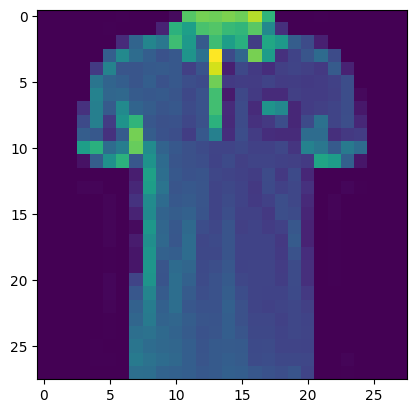

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# You can put between 0 to 59999 here
index = 988

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'LABEL: {training_labels[index]}')
print(f'\nIMAGE PIXEL ARRAY:\n {training_images[index]}')

# Visualize the image
plt.imshow(training_images[index])

In [60]:
# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0


In [61]:

# Build the classification model
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])


In [62]:
# Declare sample inputs and convert to a tensor
inputs = np.array([[1.0, 3.0, 4.0, 2.0]])
inputs = tf.convert_to_tensor(inputs)
print(f'input to softmax function: {inputs.numpy()}')

# Feed the inputs to a softmax activation function
outputs = tf.keras.activations.softmax(inputs)
print(f'output of softmax function: {outputs.numpy()}')

# Get the sum of all values after the softmax
sum = tf.reduce_sum(outputs)
print(f'sum of outputs: {sum}')

# Get the index with highest value
prediction = np.argmax(outputs)
print(f'class with highest probability: {prediction}')


input to softmax function: [[1. 3. 4. 2.]]
output of softmax function: [[0.0320586  0.23688282 0.64391426 0.08714432]]
sum of outputs: 1.0
class with highest probability: 2


In [63]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images, training_labels, epochs=10)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8250 - loss: 0.4992
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8639 - loss: 0.3760
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8771 - loss: 0.3362
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8852 - loss: 0.3120
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8923 - loss: 0.2919
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8969 - loss: 0.2780
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9007 - loss: 0.2669
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9046 - loss: 0.2560
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9089 - loss: 0.2460
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9123 - loss: 0.2375


In [64]:
# Evaluate the model on unseen data
model.evaluate(test_images, test_labels)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8808 - loss: 0.3419


[0.3419026732444763, 0.8808000087738037]

In [65]:
classifications = model.predict(test_images)

print(classifications[6])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7.1716192e-07 9.7023985e-08 3.9305724e-04 4.6514654e-07 9.9826604e-01 4.4724899e-09 1.3389401e-03 8.2582282e-15 7.0435124e-07 1.4416945e-13]


In [70]:
print(test_labels[45])

7


In [68]:
index = 4555

print("True label:", test_labels[index])
print("Predicted label:", np.argmax(classifications[index]))

True label: 3
Predicted label: 3
